In [ ]:
import torch
import torch.nn as nn
from transformers import RobertaModel, RobertaTokenizer

class RobertaCNNClassifier(nn.Module):
    def __init__(self, roberta_model='roberta-base', num_classes=2, dropout=0.5):
        super(RobertaCNNClassifier, self).__init__()
        self.roberta = RobertaModel.from_pretrained(roberta_model)
        self.conv1 = nn.Conv1d(in_channels=768, out_channels=100, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(100, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        x = x.permute(0, 2, 1)         # (batch_size, hidden_dim, seq_len)
        x = self.conv1(x)              # (batch_size, out_channels, seq_len)
        x = self.relu(x)
        x = torch.max(x, dim=2).values # Global max pooling
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

2025-08-11 15:55:38.363770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754927738.577450      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754927738.640711      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer

class VidgenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [3]:
from tqdm import tqdm

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct = 0, 0
    loop = tqdm(dataloader, desc="Training", leave=False)

    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()

        loss.backward()
        optimizer.step()

        loop.set_postfix(loss=loss.item())

    acc = total_correct / len(dataloader.dataset)
    return total_loss / len(dataloader), acc
    
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_labels = [], []

    loop = tqdm(dataloader, desc="Validating", leave=False)

    with torch.no_grad():
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_correct += (preds == labels).sum().item()

            loop.set_postfix(loss=loss.item())

    acc = total_correct / len(dataloader.dataset)
    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


In [4]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.best_f1 = 0
        self.counter = 0
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, f1, model):
        if f1 > self.best_f1 + self.delta:
            self.best_f1 = f1
            self.counter = 0
            self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [5]:
import pandas as pd
def load_vidgen_dataset(path):
    """Loads the Vidgen dataset and maps labels."""
    vidgen_df = pd.read_csv(path)
    # Ensure the column name is correct, based on your notebook it was missing but used later.
    # Assuming 'label' is the column that needs mapping.
    vidgen_df = vidgen_df[['text', 'label']] # Adjusted based on your usage
    label_map = {'nothate': 0, 'hate': 1}
    vidgen_df['label'] = vidgen_df['label'].map(label_map)
    print(f"Loaded Vidgen dataset from {path}")
    print("Vidgen Label distribution:\n", vidgen_df['label'].value_counts()) #
    return vidgen_df

In [6]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove links
    text = re.sub(r'@\w+|#\w+', '', text)                # remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', '', text)                 # remove numbers, punctuations
    return text
    


In [7]:
def load_combined_dataset(path='/kaggle/input/cyberbullying/11/combined_dataset.csv'):
    """ """
    df=pd.read_csv(path)
    print(f"Loaded combined dataset from {path}")
    print("Combined Label distribution:\n", df['label'].value_counts()) #
    return df[['text', 'label']]

In [8]:
def load_vidgen_dataset(path):
    """Loads the Vidgen dataset and maps labels."""
    vidgen_df = pd.read_csv(path)
    # Ensure the column name is correct, based on your notebook it was missing but used later.
    # Assuming 'label' is the column that needs mapping.
    vidgen_df = vidgen_df[['text', 'label']] # Adjusted based on your usage
    label_map = {'nothate': 0, 'hate': 1}
    vidgen_df['label'] = vidgen_df['label'].map(label_map)
    print(f"Loaded Vidgen dataset from {path}")
    print("Vidgen Label distribution:\n", vidgen_df['label'].value_counts()) #
    return vidgen_df


In [9]:

def load_davidson_dataset(path):
    """Loads the Davidson dataset and converts labels to binary."""
    davidson_df = pd.read_csv(path)
    davidson_df['label'] = davidson_df['class'].apply(lambda x: 0 if x == 2 else 1) #
    davidson_df['text'] = davidson_df['tweet'] # Align column name
    davidson_df.drop(columns=['class', 'tweet'], inplace=True, errors='ignore')
    print(f"Loaded Davidson dataset from {path}")
    print("Davidson Label distribution:\n", davidson_df['label'].value_counts()) #
    return davidson_df


In [10]:
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from transformers import get_scheduler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

df = load_vidgen_dataset('/kaggle/input/cyberbullying/raw/Dynamically Generated Hate Dataset v0.2.2.csv')
df["text"] = df["text"].apply(clean_text)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(), test_size=0.2, stratify=df['label']
)

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
train_dataset = VidgenDataset(train_texts, train_labels, tokenizer)
val_dataset = VidgenDataset(val_texts, val_labels, tokenizer)
print("data tokenization")
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
print("data loades")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RobertaCNNClassifier().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(class_weights)
# Apply to loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

EPOCHS = 20
early_stopper = EarlyStopping(patience=3, delta=0.001)
# Scheduler
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=EPOCHS * len(train_loader),
)
train_losses, train_accuracies = [], []
val_losses, val_accuracies, val_f1s = [], [], []
print("training")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1s.append(val_f1)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train     | Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    print(f"  Validation| Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f} | F1 Score: {val_f1:.4f}")

    early_stopper(val_f1, model)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break
    scheduler.step()
# Load best model weights after training
model.load_state_dict(early_stopper.best_model_state)


Loaded Vidgen dataset from /kaggle/input/cyberbullying/raw/Dynamically Generated Hate Dataset v0.2.2.csv
Vidgen Label distribution:
 label
1    22262
0    18993
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Epoch 17/20
  Train     | Loss: 0.3938 | Accuracy: 0.8078
  Validation| Loss: 0.5215 | Accuracy: 0.7817 | F1 Score: 0.7806


Epoch 18/20
  Train     | Loss: 0.3853 | Accuracy: 0.8127
  Validation| Loss: 0.5247 | Accuracy: 0.7805 | F1 Score: 0.7797


Epoch 19/20
  Train     | Loss: 0.3775 | Accuracy: 0.8156
  Validation| Loss: 0.5086 | Accuracy: 0.7857 | F1 Score: 0.7840


Epoch 20/20
  Train     | Loss: 0.3706 | Accuracy: 0.8179
  Validation| Loss: 0.5114 | Accuracy: 0.7820 | F1 Score: 0.7784


<All keys matched successfully>

In [11]:
torch.save(model.state_dict(),"roberta_cnn.pth")


In [12]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, val_f1s):
    epochs = range(1, len(train_losses)+1)
    plt.figure(figsize=(16,5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, val_accuracies, label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_f1s, label='Val F1', color='purple')
    plt.title('F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1')
    plt.legend()

    plt.tight_layout()
    plt.show()


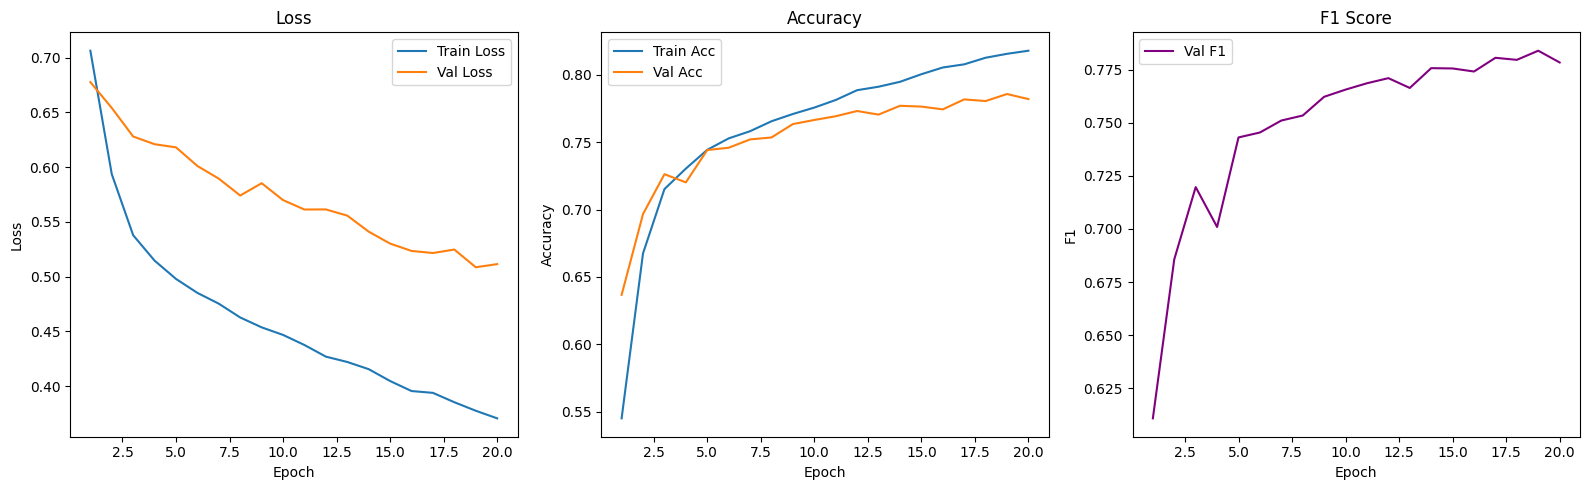

In [13]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, val_f1s)


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

def final_evaluation(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds) #
    precision = precision_score(all_labels, all_preds) #
    recall = recall_score(all_labels, all_preds) #
    f1 = f1_score(all_labels, all_preds) #

    print("\nClassification Report:")
    print(f"Accuracy:  {accuracy:.4f}") #
    print(f"Precision: {precision:.4f}") #
    print(f"Recall:    {recall:.4f}") #
    print(f"F1-Score:  {f1:.4f}") #
    print(classification_report(all_labels, all_preds, target_names=['Not Hate', 'Hate']))

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()



Classification Report:
Accuracy:  0.7820
Precision: 0.7741
Recall:    0.8414
F1-Score:  0.8064
              precision    recall  f1-score   support

    Not Hate       0.79      0.71      0.75      3799
        Hate       0.77      0.84      0.81      4452

    accuracy                           0.78      8251
   macro avg       0.78      0.78      0.78      8251
weighted avg       0.78      0.78      0.78      8251



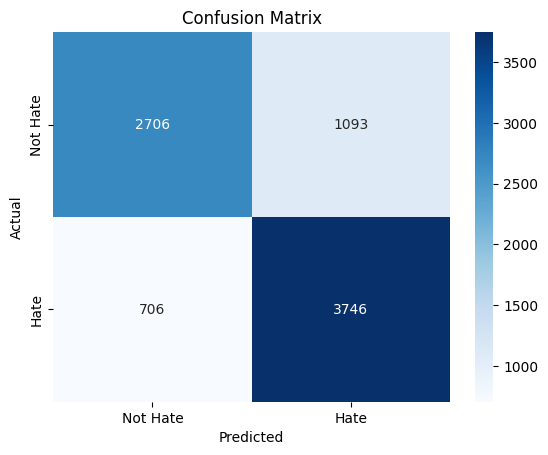

In [15]:
final_evaluation(model, val_loader, device)
